导入 NumPy 库，用于数值计算（数组、矩阵、数学函数）。在机器学习中，数据格式最终都需转为 NumPy 数组。
导入 Pandas，用于数据读取、清洗、转换，提供 DataFrame 数据结构，是数据处理的核心工具。
导入 Matplotlib 的 pyplot 模块，用于绘图（折线图、柱状图等），是可视化的底层库。
导入 Seaborn，基于 Matplotlib 的高级可视化库，提供更美观地统计图形（如箱线图、热力图），简化代码。
从 Scikit-learn 的 tree 模块导入：
• DecisionTreeClassifier：决策树分类器（用于训练模型）。
• plot_tree：决策树可视化函数，可直接绘制树结构。
从 model_selection 模块导入：
• train_test_split：将数据集划分为训练集和测试集，防止数据泄露并评估泛化能力。
• GridSearchCV：网格搜索 + 交叉验证，自动寻找最佳超参数组合。
从 metrics 模块导入评估指标：
• accuracy_score：准确率（预测正确的比例）。
• classification_report：详细报告（精确率、召回率、F1-score等）。
• confusion_matrix：混淆矩阵（真实 vs 预测的计数矩阵）。
导入警告模块并忽略所有警告，避免训练过程中产生的冗余输出干扰分析（仅在调试友好时使用，生产环境中不建议盲目忽略）

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import warnings
warnings.filterwarnings('ignore')
print("库加载成功")

库加载成功


1.使用 Pandas 读取当前目录下的 CSV 文件 train.csv，加载为 DataFrame 对象 df。该文件包含泰坦尼克号的训练数据（891行，12列）。2.打印数据集的形状（行数, 列数）。预期为 (891, 12)。3.列出所有列名，方便后续操作。常见列：PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked。4.显示前 5 行数据，快速检查数据内容和格式（有无缺失值、数据类型等）。

In [58]:
df=pd.read_csv('train.csv')
print(f"数据集形状：{df.shape}")
print(f"列名：{df.columns.tolist()}")
df.head()

数据集形状：(891, 12)
列名：['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


1.创建画布，指定宽6英寸、高4英寸。2.绘制计数柱状图，x轴为 Survived 列（0/1），y轴为对应样本数，直观显示死亡与幸存的人数。3.设置图表标题。4.显示图形。5.计算幸存者的比例（Survived 列的平均值），按百分比格式打印。例如 0.38 显示为 "38.00%" 。4.新建一个 8×4 的画布。5.将画布分成一行两列，选择第一个子图。6.绘制按性别分组的计数柱状图，hue='Survived' 将幸存和死亡用不同颜色区分，可看出不同性别中存活数量。7.设置子图标题。
8.选择第二个子图。9.绘制柱状图，x轴为性别，y轴为 Survived 的平均值（即生存率），自动计算置信区间（竖线）。10.子图标题。11.自动调整子图间距，避免标签重叠。

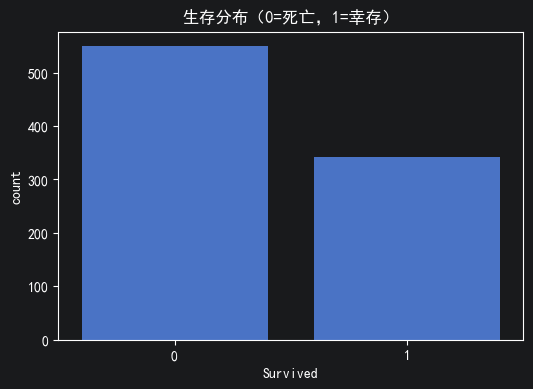

幸存比例：0.38


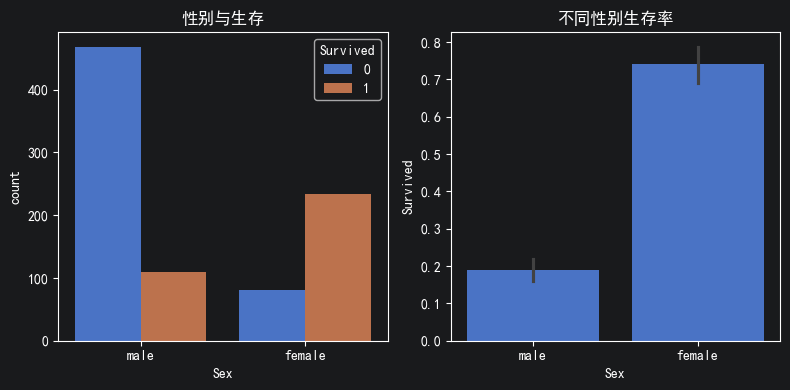

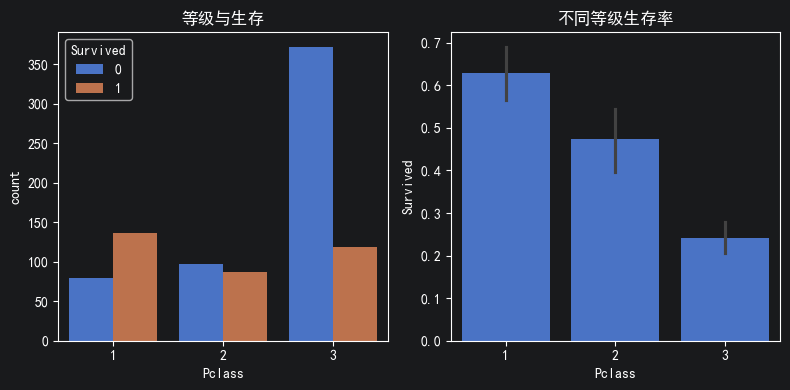

In [59]:
plt.rcParams['font.sans-serif']=['SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus']=False
#生存率分布
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Survived')
plt.title('生存分布（0=死亡，1=幸存）')
plt.show()
print(f"幸存比例：{df['Survived'].mean():.2f}")
#性别与生存
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.countplot(data=df,x='Sex',hue='Survived')
plt.title('性别与生存')
plt.subplot(1,2,2)
sns.barplot(data=df,x='Sex',y='Survived')
plt.title('不同性别生存率')
plt.tight_layout()
#船舱等级与生存
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.countplot(data=df,x='Pclass',hue='Survived')
plt.title('等级与生存')
plt.subplot(1,2,2)
sns.barplot(data=df,x='Pclass',y='Survived')
plt.title('不同等级生存率')
plt.tight_layout()

1.定义要使用的特征列名，未选择 PassengerId, Name, Ticket, Cabin（原因：ID无意义，姓名过于离散，票号杂乱，Cabin缺失过多）。2.目标变量列名。3.从原始数据中选取所需特征和目标列，并创建副本，避免修改原始数据（.copy() 保证独立性）。4.打印每列的缺失值数量。常见缺失：Age（177个）、Embarked（2个）。5.使用中位数填充 Age 缺失值。中位数对异常值不敏感，比均值更适合偏态分布。inplace=True 直接在原列修改。6.使用众数（出现最多的值，如'S'）填充 Embarked 缺失值。仅2个缺失，可直接用最常见港口填充。7.将 Sex 列从文本映射为数值：男性→0，女性→1。因为决策树能处理数值，但标签编码比One-Hot更合适（二分类特征）。8.对 Embarked 进行 One-Hot 编码，生成两个虚拟列（Embarked_Q, Embarked_S），drop_first=True 去掉第一个类别（如 Embarked_C）以避免多重共线性（对于树模型其实不必须，但习惯保留）。9.	输出处理后数据形状和预览。最后特征数：7 原始特征 + 2 虚拟列 = 9 列（不含目标），共891行。

In [60]:
features=['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
target='Survived'
df_ml=df[features+[target]].copy()
print("缺失值统计:")
print(df_ml.isnull().sum())
df_ml['Age'].fillna(df_ml['Age'].median(),inplace=True)
df_ml['Embarked'].fillna(df_ml['Embarked'].mode()[0], inplace=True)
df_ml['Sex']=df_ml['Sex'].map({'male':1,'female':0})
df_ml=pd.get_dummies(df_ml,columns=['Embarked'],prefix='Embarked',drop_first=True)
print(f"\n特征工程后数据形状：{df_ml.shape}")
df_ml.head()

缺失值统计:
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Survived      0
dtype: int64

特征工程后数据形状：(891, 9)


,Pclass,Sex,Age,SibSp,Parch,Fare,Survived,Embarked_Q,Embarked_S
0,3,1,22.0,1,0,7.2500,0,False,True
1,1,0,38.0,1,0,71.2833,1,False,False
2,3,0,26.0,0,0,7.9250,1,False,True
3,1,0,35.0,1,0,53.1000,1,False,True
4,3,1,35.0,0,0,8.0500,0,False,True


1.从 DataFrame 中移除目标列，得到特征矩阵 X（891行 × 9列）。2.提取目标标签序列 y（0/1）。3.将数据随机划分为训练集和测试集：test_size=0.2：测试集占20%。,random_state=42：固定随机种子，保证结果可复现,stratify=y：分层抽样，保持训练集和测试集中幸存比例与原始数据一致（约38%）。4.输出划分后的形状，并验证分层是否成功（训练集和测试集的幸存率应接近）。

In [61]:
X=df_ml.drop('Survived',axis=1)
y=df_ml['Survived']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"训练集：{X_train.shape}，测试集：{X_test.shape}")
print(f"训练集幸存率：{y_train.mean():.2%},测试集幸存率：{y_test.mean():.2%}")

训练集：(712, 8)，测试集：(179, 8)
训练集幸存率：38.34%,测试集幸存率：38.55%


1.创建一个默认参数的决策树分类器（不限制深度、不限制叶节点最小样本数）。random_state 保证结果一致性。2.使用训练数据训练模型。3.计算模型在训练集上的准确率（正确预测比例）。4.计算模型在测试集上的准确率。5.输出对比结果：通常训练集准确率接近100%（由于树完全生长，记住了数据），测试集准确率较低（约70%-80%），同时打印树的深度和叶节点数，直观展示未剪枝树的复杂性（深度可能 20+，叶节点数 100+）。

In [62]:
tree_full=DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train,y_train)
train_acc=tree_full.score(X_train,y_train)
test_acc=tree_full.score(X_test,y_test)
print(f"未剪枝决策树")
print(f"训练集准确率:{train_acc:.3f}")
print(f"测试集准确率:{test_acc:.3f}")
print(f"树深度:{tree_full.get_depth()}")
print(f"叶节点树:{tree_full.get_n_leaves()}")

未剪枝决策树
训练集准确率:0.982
测试集准确率:0.821
树深度:23
叶节点树:153


1.定义超参数搜索空间：max_depth：树的最大深度（3~10），控制过拟合。min_samples_split：内部节点再划分所需的最小样本数（10/20/50）。min_samples_leaf：叶节点最少样本数（5/10/20）。criterion：分裂标准（基尼系数或信息熵）。2.创建网格搜索对象：估计器：DecisionTreeClassifier(random_state=42)。param_grid：上述参数组合。cv=5：5折交叉验证（每次用4折训练1折验证）。scoring='accuracy'：优化目标为准确率。n_jobs=-1：使用所有CPU并行计算，加速搜索。verbose=1：输出进度。3.执行网格搜索，对每一组参数训练5次（交叉验证），取平均得分。4.获取表现最佳的超参数组合（如 {'criterion': 'gini', 'max_depth': 5. 'min_samples_leaf': 5, 'min_samples_split': 20}）。6.最佳参数对应的交叉验证平均准确率。7.	提取训练好的最佳模型（已用全部训练数据重新训练）。8.在测试集上评估最终模型，得到未参与调参的泛化准确率（通常高于未剪枝的测试结果，且略低于交叉验证得分）。

In [63]:
param_grid={
    'max_depth':[3,4,5,6,8,10],
    'min_samples_split':[10,20,50],
    'min_samples_leaf':[5,10,20],
    'criterion':['gini','entropy']
}
grid=GridSearchCV(DecisionTreeClassifier(random_state=42),
                  param_grid,
                  cv=5,
                  scoring='accuracy',
                  n_jobs=-1,
                  verbose=1)
grid.fit(X_train,y_train)
print(f"\n最佳参数：{grid.best_params_}")
print(f"最佳交叉验证得分：{grid.best_score_:.3f}")
best_tree=grid.best_estimator_
test_acc=best_tree.score(X_test,y_test)
print(f"测试集准确率：{test_acc:.3f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

最佳参数：{'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 10}
最佳交叉验证得分：0.826
测试集准确率：0.777


1.使用最佳模型对测试集进行预测，得到预测标签（0/1）。2.打印分类报告，包含每个类别的精确率、召回率、F1-score及支持度（样本数）。target_names 自定义显示名称。3.计算混淆矩阵：[[TN, FP], [FN, TP]]。4.用热力图可视化混淆矩阵：annot=True：在格子中显示数值。fmt='d'：整数格式。cmap='Blues'：颜色蓝调。xticklabels/yticklabels：设置坐标轴标签为“预测死亡/幸存”和“实际死亡/幸存”。5.设置标题和坐标轴标签。

分类报告：
              precision    recall  f1-score   support

          死亡       0.78      0.88      0.83       110
          生存       0.76      0.61      0.68        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.75       179
weighted avg       0.78      0.78      0.77       179



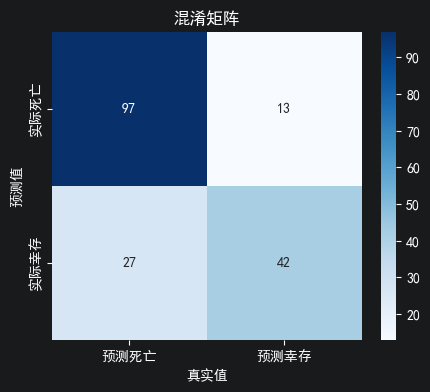

In [64]:
y_pred=best_tree.predict(X_test)
print("分类报告：")
print(classification_report(y_test,y_pred,target_names=['死亡','生存']))
plt.figure(figsize=(5,4))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['预测死亡','预测幸存'],yticklabels=['实际死亡','实际幸存'])
plt.title('混淆矩阵')
plt.xlabel('真实值')
plt.ylabel('预测值')
plt.show()

1.设置画布大小（宽20英寸，高12英寸），确保树形图完整显示。
2.绘制决策树：
• best_tree：已训练好的模型。
• feature_names：特征名称列表（9个），用于节点显示。
• class_names：类别名称，对应目标值0/1。
• filled=True：根据类别填充颜色（通常橙色/蓝色区分）。
• rounded=True：圆角节点。
• fontsize=10：节点内文字大小。
• impurity=False：不显示不纯度值（gini/entropy），避免信息过载。
• proportion=True：节点中的值显示为比例（如 [0.3, 0.7]），而非绝对计数。
3.添加标题，显示测试集准确率。
4.显示图像。

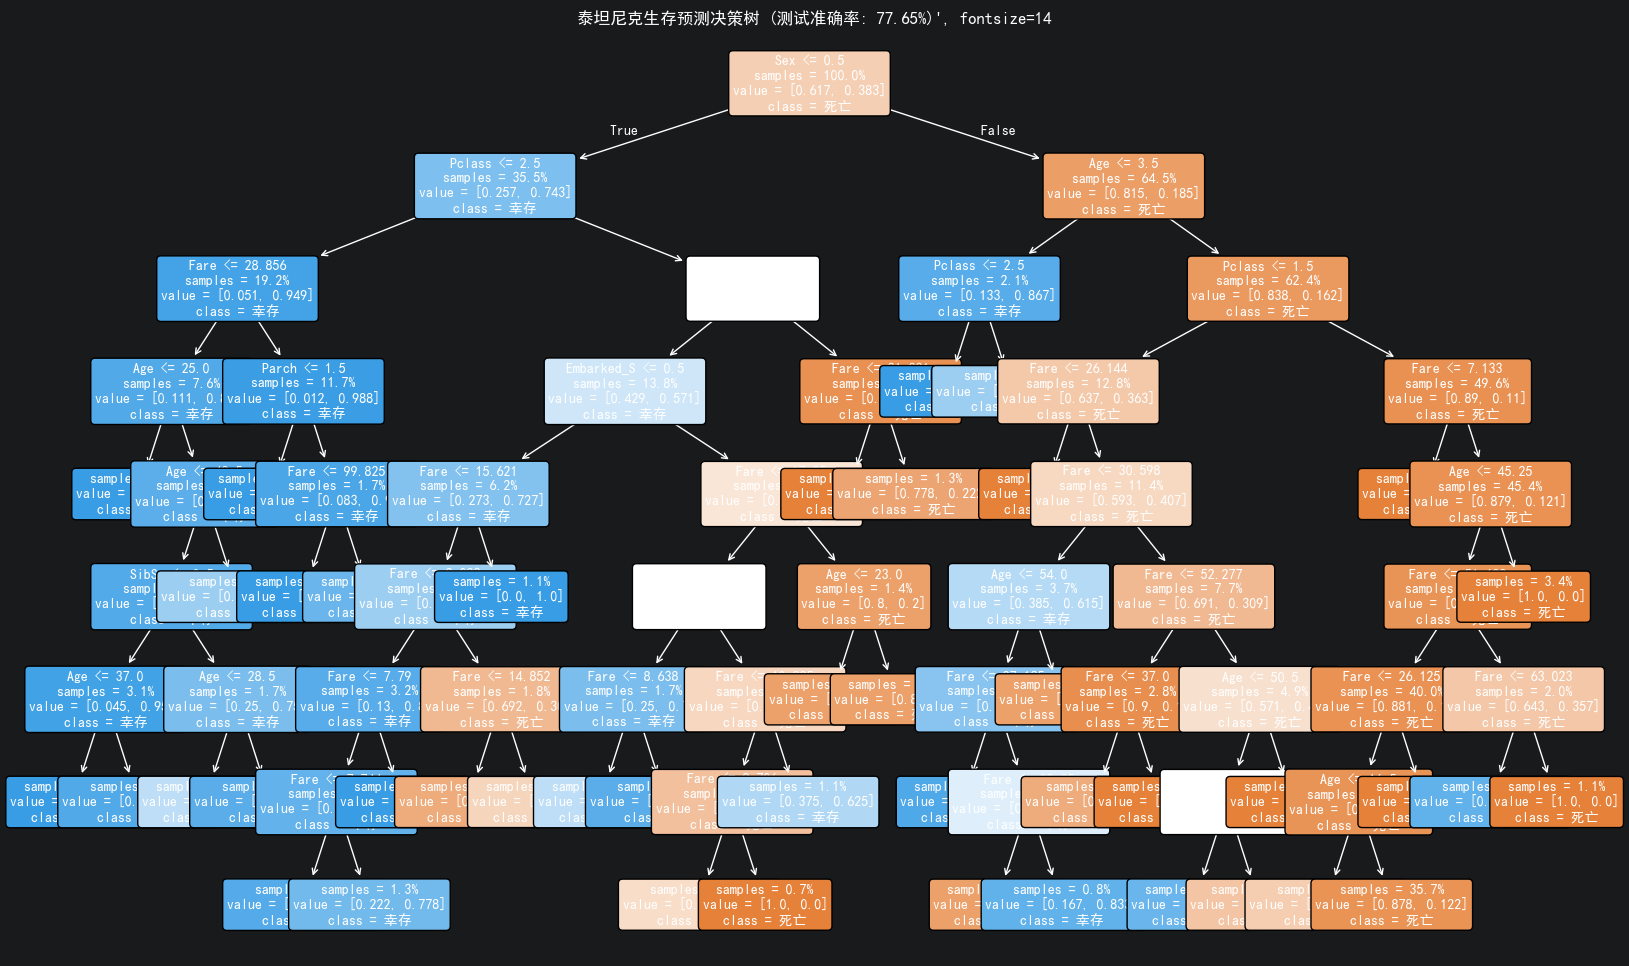

In [65]:
plt.figure(figsize=(20,12))
plot_tree(best_tree,feature_names=X.columns.tolist(),class_names=['死亡','幸存'],filled=True,rounded=True,fontsize=10,impurity=False,proportion=True)
plt.title(f"泰坦尼克生存预测决策树 (测试准确率: {test_acc:.2%})', fontsize=14")
plt.savefig('decision_tree.png')
plt.show()

1.创建 DataFrame 存储特征及其重要性得分（best_tree.feature_importances_ 是数组，顺序与 X.columns 一致）。按重要性降序排序。2.新建画布。3.绘制水平条形图，x轴为重要性得分，y轴为特征名，颜色使用 viridis 调色板。4.设置标题、标签、自动调整布局。5.以无索引格式打印特征重要性排名表。

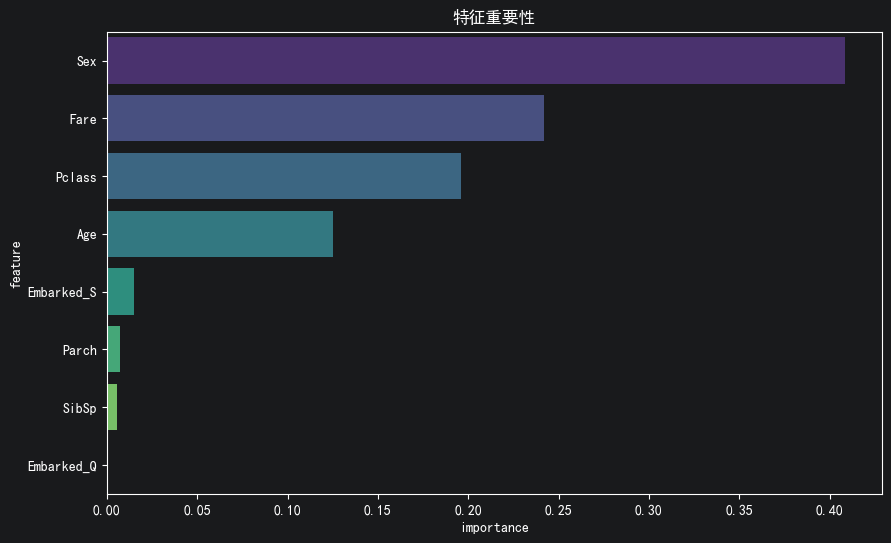

特征重要性排名：
   feature  importance
       Sex    0.408578
      Fare    0.242153
    Pclass    0.195996
       Age    0.125324
Embarked_S    0.015047
     Parch    0.007327
     SibSp    0.005574
Embarked_Q    0.000000


In [66]:
importance=pd.DataFrame({
    'feature':X.columns,
    'importance':best_tree.feature_importances_
}).sort_values('importance',ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x='importance',y='feature',palette='viridis')
plt.title("特征重要性")
plt.show()
print("特征重要性排名：")
print(importance.to_string(index=False))

In [67]:
test_df=pd.read_csv('test.csv')
passenger_ids=test_df['PassengerId']
print(f"测试集样本数：{len(test_df)}")
features=['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
test_ml=test_df[features].copy()
test_ml['Age'].fillna(df['Age'].median(),inplace=True)
test_ml['Fare'].fillna(df['Fare'].median(),inplace=True)
test_ml['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
test_ml['Sex']=test_ml['Sex'].map({'male':1,'female':0})
test_ml=pd.get_dummies(test_ml,columns=['Embarked'],prefix='Embarked',drop_first=True)
test_ml=test_ml.reindex(columns=X.columns,fill_value=0)
test_predictions=best_tree.predict(test_ml)
submission=pd.DataFrame({'PassengerId': passenger_ids,'Survived': test_predictions})
submission.to_csv('submission.csv',index=False)
print("提交文件已生成：submission.csv")
print(submission.head())

测试集样本数：418
提交文件已生成：submission.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
